In [106]:
import pandas as pd
import duckdb as db
import matplotlib.pyplot as plt

from datetime import datetime
from prophet import Prophet

from prophet.plot import plot_plotly, plot_components_plotly  

In [9]:
df = pd.read_csv('../../../data/TrafficPerTerritory.csv')

In [10]:
df['Month'] = pd.to_datetime(df['Month'], format="%Y-%m-%d")

In [11]:
df_plot = df.loc[(df['AirServiceId'] == 0) & (df['AircraftMovementId'] == 2) & (df['IslandId'] == 0) & (df['StopoverTerritoryId'] == 9)].copy(deep=True)

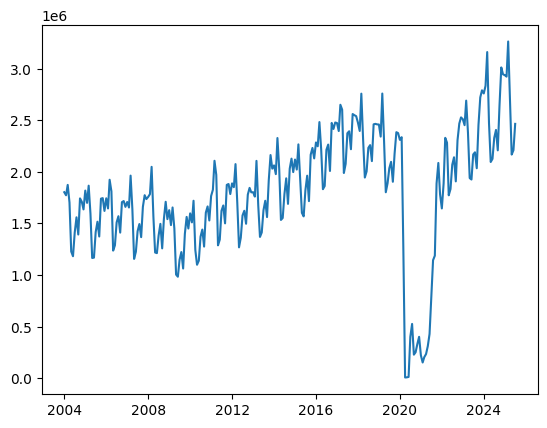

In [12]:
plt.plot(df_plot['Month'], df_plot['Passengers'])

As we can see in the plot above, COVID created an outlier period in the data. To handle this we will use the Prophet model and set those values to None, this way the model will handle the missing data automatically by interpolating through the period withouth letting it affect the model's understanding of normal patterns

In [181]:
# Total Passengers that arrive to Gran Canaria per month
df_prophet = df.loc[(df['AirServiceId'] == 0) & (df['AircraftMovementId'] == 2) & (df['IslandId'] == 3) & (df['StopoverTerritoryId'] != 0)].copy(deep=True)

In [182]:
s = df_prophet.groupby('Month').sum()

In [183]:
df_prophet = s[['Passengers']].copy(deep=True)


df_prophet.reset_index(inplace=True)

df_prophet.rename({'Month': 'ds', 'Passengers': 'y'}, axis=1, inplace=True)

In [184]:
df_prophet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      259 non-null    datetime64[ns]
 1   y       259 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.2 KB


In [185]:
df_prophet.loc[(df_prophet['ds'] >= '2020-03-01') & (df_prophet['ds'] < '2022-06-01'), 'y'] = None

In [186]:
df_prophet.loc[(df_prophet['ds'] >= '2020-03-01') & (df_prophet['ds'] < '2022-06-01')]

,ds,y
194,2020-03-01,NaN
195,2020-04-01,NaN
196,2020-05-01,NaN
197,2020-06-01,NaN
198,2020-07-01,NaN
199,2020-08-01,NaN
200,2020-09-01,NaN
201,2020-10-01,NaN
202,2020-11-01,NaN
203,2020-12-01,NaN


In [187]:
m = Prophet()
m.fit(df_prophet)

20:16:23 - cmdstanpy - INFO - Chain [1] start processing
20:16:23 - cmdstanpy - INFO - Chain [1] done processing


In [188]:
future = m.make_future_dataframe(periods=12, freq='MS') 

In [189]:
forecast = m.predict(future)

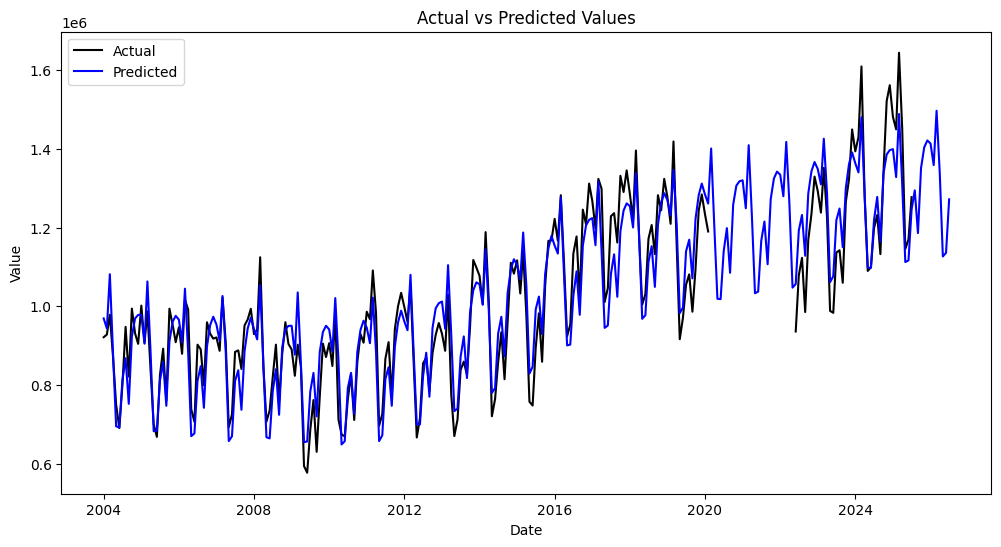

In [190]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual', color='black')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted', color='blue')
plt.legend()
plt.title('Actual vs Predicted Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

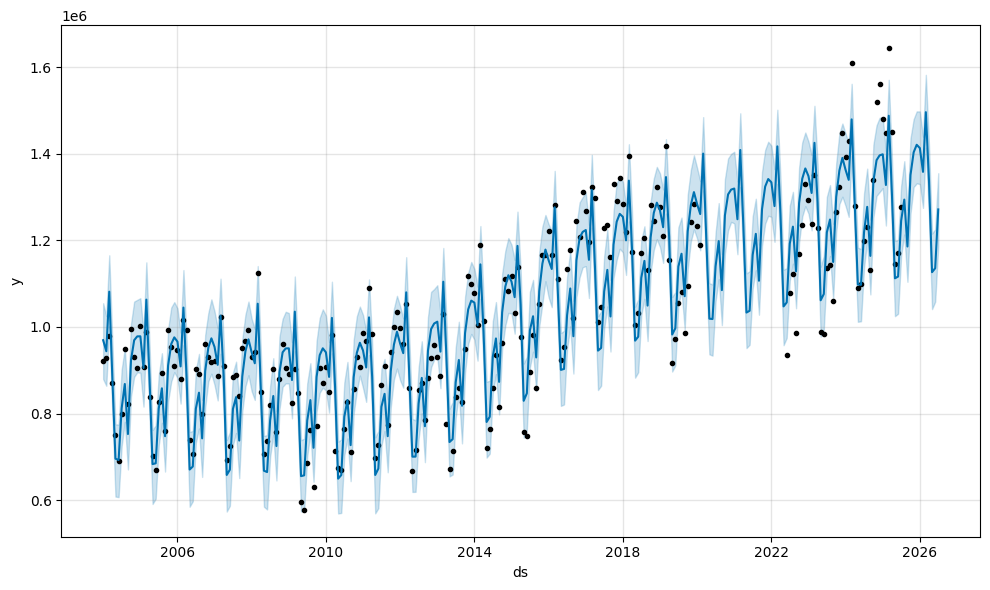

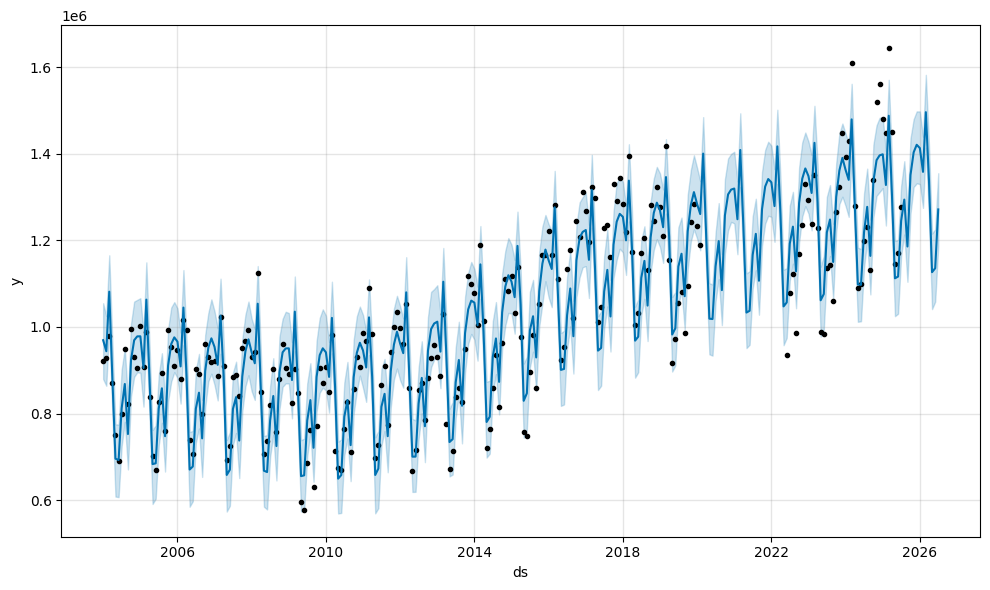

In [191]:
m.plot(forecast)

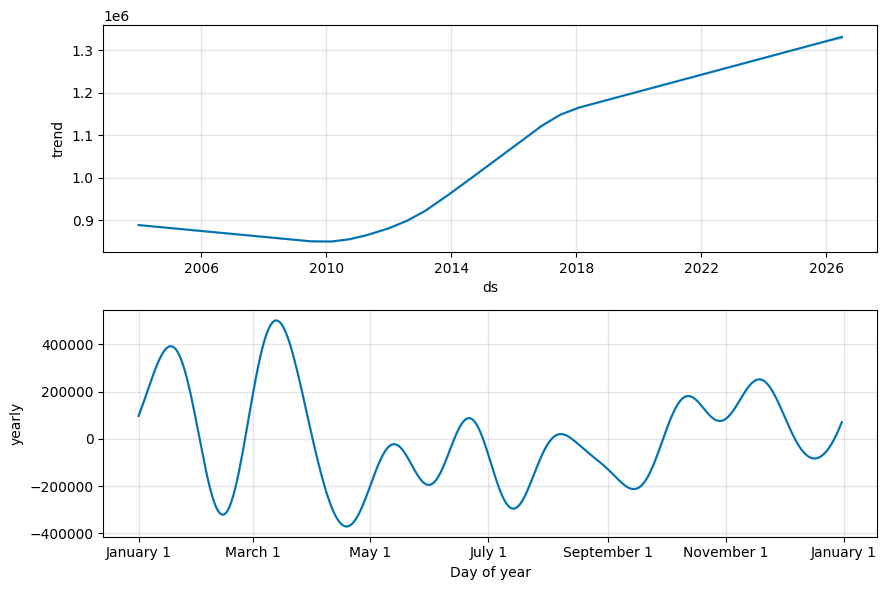

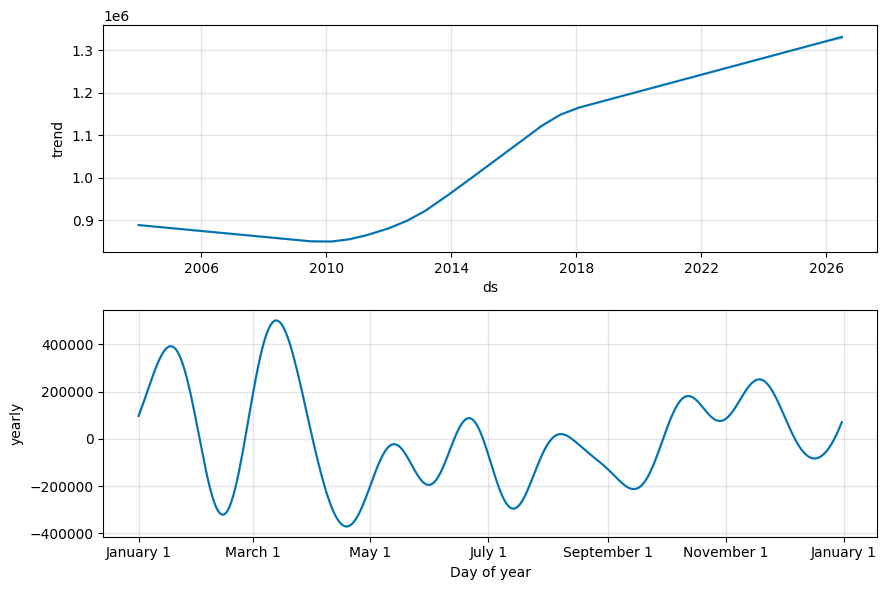

In [192]:
m.plot_components(forecast)